#Trabalho prático # 1
##Modelagem matemática e Computacional

###Tópico: Força e movimento

---

Nome: Davi dos Santos Mattos

DRE: 119133049


---

**Instruções:**

**Faça uma cópia deste notebook no seu drive, preencha-lo com seus dados, escreva e execute seus códigos antes de entregar o trabalho.**

**Inclua  um relatório, na parte final do notebook,** com suas conclusões, respostas, observações e comentários relacionados às questões abordadas nas tarefas.  

**A elaboração dos códigos pode ser realizada em duplas, mas o resto do trabalho é individual.**

**Não é permitido o uso de IA no desenvolvimento do trabalho.**

*Se você fez o seu trabalho em dupla inclua essa informação no relatório. Além disso, se você  também recebeu ajuda de um(a) colega/amigo(a) ou consultou/usou informações da internet ou outras fontes, coloque referências à elas no seu relatório.*


**Entrega do trabalho:**

*Na entrega do seu trabalho, inclua  o arquivo do seu notebook (.ipynb) diretamente do seu google drive. **Não serão aceitos links para o arquivo**.*

*Data de entrega: 12/junho/2026*

---


A força de atração gravitacional que um corpo de massa $m_1$ exerce no corpo de massa $m_2$ é modelada segundo a lei de gravitação universal de Newton, dada pela equação $$\vec{F}_{12} =  -\frac{Gm_1m_2}{{r}^2}\vec{e}_{12}$$
em que $G$ é a constante de gravitação universal, $r$ a distância entre os corpo e $\vec{e}_{12}$ o vetor unitário direcionado do primeiro para o segundo corpo.

Na modelagem do movimento de corpos celestes no sistema solar é usado o seguinte sistema de unidades fundamentais:

* Comprimento: $1 \,{AU}$ (Unidade Astronômica $\approx$ Distância média Terra-Sol);
* Massa: $1 \,{M}_{\odot}$ (Massa do Sol $\approx 1.98\times 10^{30}\,kg$);
* Tempo: $1\,ano$.

Para a constante de gravitação universal temos que
$$ G = 4\pi^2\;\frac{AU^3}{{M}_{\odot}\times ano^2}.$$


##Tarefa #1:

Implemente um código em Python para simular o movimento do sistema Sol-Terra.

a)  Calcule a evolução do sistema para um período de $2\,\text{anos}$, usando os seguintes dados:


*   Terra:
    1.   Posição inicial: $x_0 = 0.9832\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = 6.2835\,AU/ano$,
    3.   Massa: $m_1 = 3.003\times 10^{-6}\,{M}_{\odot}$
*   Sol:
    1.   Posição inicial: $x_0 = -2.95\times 10^{-6}\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = -1.887\times 10^{-5}\,AU/ano$,
    3.   Massa: $m_2 = 1\,{M}_{\odot}$


b) Mostre os gráficos das trajetórias de cada corpo no plano $XY$, da evolução das coordenadas de cada corpo e da distância entre os dois corpos ao longo do tempo.


---


**Observação**: Use as funcionalidades do [NumPy](https://numpy.org)  para trabalhar com  vetores (*arrays* de dados), do [SciPy](https://scipy.org/) para a resolução de problemas para EDOs (função [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp)) e do [MatPlotLib](https://matplotlib.org/) para a visualização dos resultados.

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

G = 4 * np.pi**2  # Constante gravitacional

# Planeta Terra
x_terra = [0.9832, 0.0]
v_terra = [0.0, 6.2835]
m_terra = 3.003e-6

# Sol
x_sol = [-2.95e-6, 0.0]
v_sol = [0.0, -1.887e-5]
m_sol = 1.0

def derivadas(t, vetor):
  x1, y1, vx1, vy1 = vetor[0], vetor[1], vetor[2], vetor[3] # Terra
  x2, y2, vx2, vy2 = vetor[4], vetor[5], vetor[6], vetor[7] # Sol

  #Distâncias
  x_dist = x2 - x1
  y_dist = y2 - y1
  r = np.sqrt(x_dist**2 + y_dist**2)

  # Corpo 1 (Terra sendo atraida pelo Sol)
  ax1 = G * m_sol * x_dist / r**3
  ay1 = G * m_sol * y_dist / r**3

  # Corpo 2 (Sol atraido pela Terra)
  ax2 = -G * m_terra * x_dist / r**3
  ay2 = -G * m_terra * y_dist / r**3

  return [vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2]

vetor_0 = [x_terra[0], x_terra[1], v_terra[0], v_terra[1], x_sol[0], x_sol[1], v_sol[0], v_sol[1]]

delta_t = (0,2) # 2 Anos
pontos = np.linspace(0,2,1000)

solucao = solve_ivp(
    fun =derivadas,
    t_span = delta_t,
    y0=vetor_0,
    t_eval = pontos,
    method = 'RK45',
    rtol = 1e-6,
    atol = 1e-6
)

Resultados

In [76]:
x_terra = solucao.y[0]
y_terra = solucao.y[1]
x_sol = solucao.y[4]
y_sol = solucao.y[5]
t = solucao.t

r = np.sqrt((x_terra - x_sol)**2 + (y_terra - y_sol)**2)


print(f""" -- Posição após 2 anos --\n
Terra: x = {x_terra[-1]} AU, y = {y_terra[-1]} AU
Sol: x = {x_sol[-1]} AU,  y = {y_sol[-1]} AU
""")

 -- Posição após 2 anos --

Terra: x = 0.7927593744480881 AU, y = 0.5761066748608574 AU
Sol: x = -2.378106801467606e-06 AU,  y = -1.7313473446071507e-06 AU



Plotando gráficos

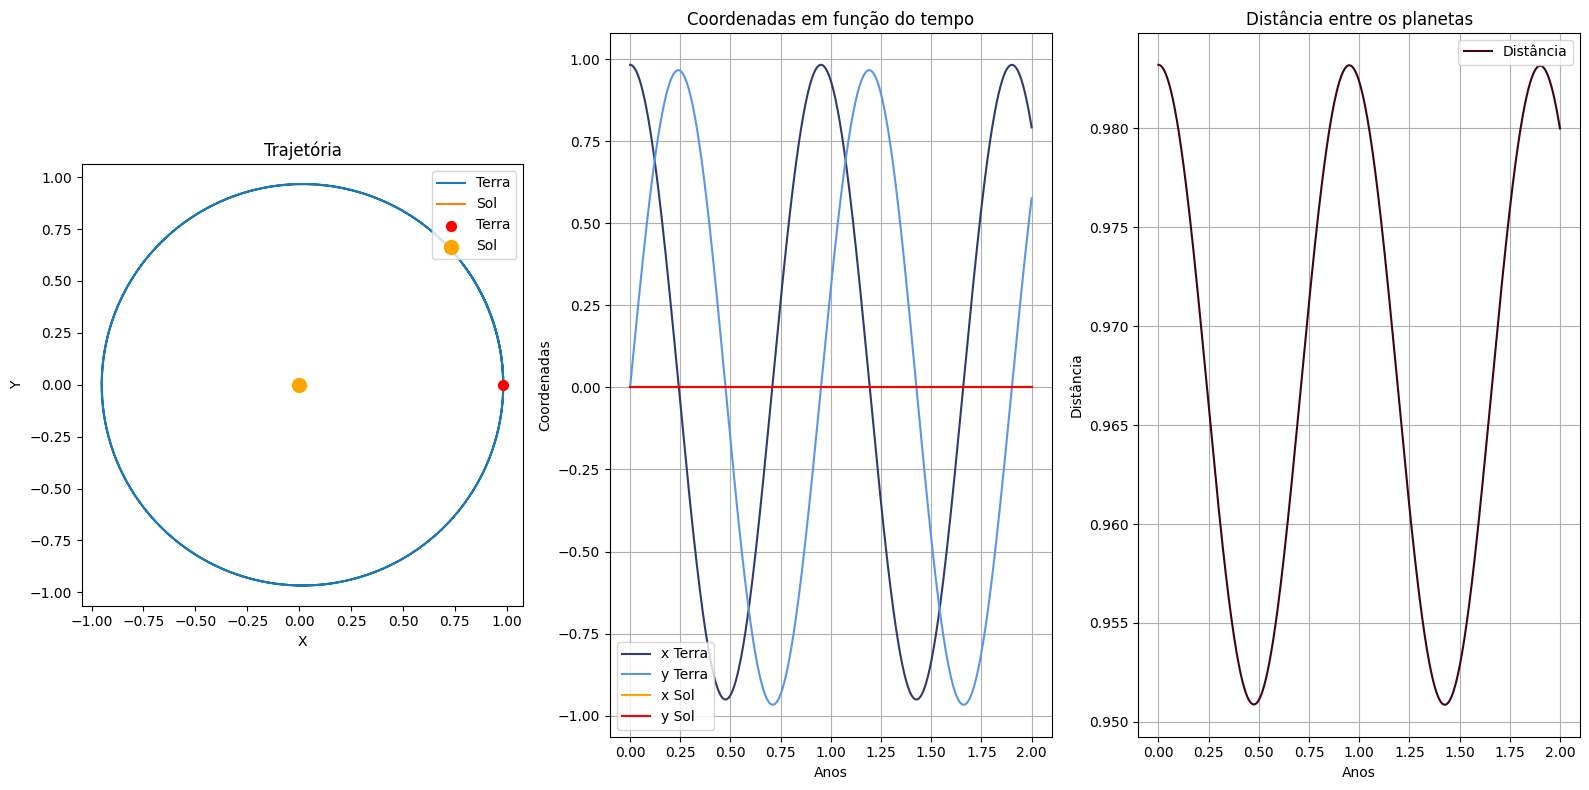

In [77]:
fig, axs = plt.subplots(1, 3, figsize=(16, 8))

# Gráfico 1 - Trajetória
ax_traj = axs[0]

pos_inicial_terra = (x_terra[0], y_terra[0])
pos_inicial_sol = (x_sol[0], y_sol[0])

ax_traj.plot(x_terra, y_terra, label='Terra')
ax_traj.plot(x_sol, y_sol, label='Sol')
ax_traj.scatter(*pos_inicial_terra, color='red', s=50, zorder=5, label="Terra")
ax_traj.scatter(*pos_inicial_sol, color='orange', s=100, zorder=5, label="Sol")
ax_traj.set_xlabel('X')
ax_traj.set_ylabel('Y')
ax_traj.set_title('Trajetória')
ax_traj.set_aspect('equal')
ax_traj.legend()

# Gráfico 2 - Coordenadas em função do tempo

ax_coord = axs[1]

ax_coord.plot(t, x_terra, label='x Terra', color='#323871')
ax_coord.plot(t, y_terra, label='y Terra', color='#5995ED')
ax_coord.plot(t, x_sol,   label='x Sol',   color='orange')
ax_coord.plot(t, y_sol,   label='y Sol',   color='red')
ax_coord.set_xlabel('Anos')
ax_coord.set_ylabel('Coordenadas')
ax_coord.set_title('Coordenadas em função do tempo')
ax_coord.legend()
ax_coord.grid(True)

# Gráfico 3 - Distância entre os planetas

ax_dist = axs[2]

ax_dist.plot(t, r, label='Distância', color="#420217")
ax_dist.set_xlabel('Anos')
ax_dist.set_ylabel('Distância')
ax_dist.set_title('Distância entre os planetas')
ax_dist.legend()
ax_dist.grid(True)

plt.tight_layout()
plt.show()

##Tarefa #2:

Implemente um código em Python para simular a evolução de um sistema de três estrelas.

a)  Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:

*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533/(4\pi^2)\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$


b) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

c) Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:

*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.166203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533/(4\pi^2)\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.766203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$

d) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

e) Descreva qualitativamente os movimentos do sistema calculados nos itens a) e c). Indique semelhanças e diferenças entre esses dois cenários.

a)

In [78]:
# Massas
m1 = 0.02533 / (4*np.pi**2)
m2 = 0.02533
m3 = 0.02533

y0_a = [
     0.970043, -0.243087,  0.466203,  0.432365,   # Estrela 1
    -0.970043,  0.243087,  0.466203,  0.432365,   # Estrela 2
     0.0,       0.0,      -0.932406, -0.864730    # Estrela 3
]

t_span = (0, 10.5) # 10.5 anos
t_eval = np.linspace(0, 10.5, 50000)

def derivadas3corpos(t, y, m1, m2, m3):

    x1, y1, vx1, vy1 = y[0], y[1], y[2],  y[3]
    x2, y2, vx2, vy2 = y[4], y[5], y[6],  y[7]
    x3, y3, vx3, vy3 = y[8], y[9], y[10], y[11]

    # Distâncias entre cada par
    r12 = np.sqrt((x2-x1)**2 + (y2-y1)**2)
    r13 = np.sqrt((x3-x1)**2 + (y3-y1)**2)
    r23 = np.sqrt((x3-x2)**2 + (y3-y2)**2)

    # Estrela 1
    ax1 = G*m2*(x2-x1)/r12**3 + G*m3*(x3-x1)/r13**3
    ay1 = G*m2*(y2-y1)/r12**3 + G*m3*(y3-y1)/r13**3

    # Estrela 2
    ax2 = G*m1*(x1-x2)/r12**3 + G*m3*(x3-x2)/r23**3
    ay2 = G*m1*(y1-y2)/r12**3 + G*m3*(y3-y2)/r23**3

    # Estrela 3
    ax3 = G*m1*(x1-x3)/r13**3 + G*m2*(x2-x3)/r23**3
    ay3 = G*m1*(y1-y3)/r13**3 + G*m2*(y2-y3)/r23**3

    return [vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2, vx3, vy3, ax3, ay3]

In [79]:
t_span = (0, 10.5)
t_eval = np.linspace(0, 10.5, 50000)

sol_a = solve_ivp(
    fun=lambda t, y: derivadas3corpos(t, y, m1, m2, m3),
    t_span=t_span,
    y0=y0_a,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-9,
    atol=1e-9
)


x1, y1 = sol_a.y[0], sol_a.y[1]
x2, y2 = sol_a.y[4], sol_a.y[5]
x3, y3 = sol_a.y[8], sol_a.y[9]
t = sol_a.t

print(f" -- Posição após 10.5 anos --")
print(f"""
Estrela 1: [{x1[-1]}, {y1[-1]}] AU
Estrela 2: [{x2[-1]}, {y2[-1]}] AU
Estrela 3: [{x3[-1]}, {y3[-1]}] AU
""")

 -- Posição após 10.5 anos --

Estrela 1: [-8.856922401174563, 2.337515786758629] AU
Estrela 2: [-1.3261255253334865, -5.133732360790708] AU
Estrela 3: [-4.1661339037354645, 0.886614729183922] AU



b)

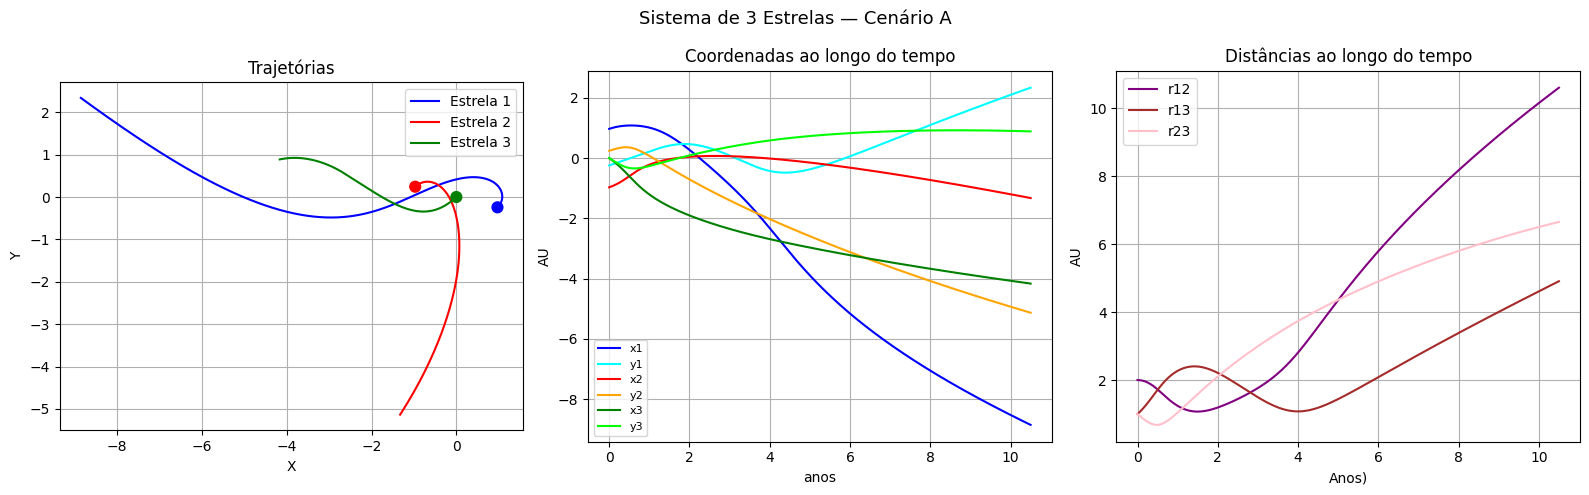

In [80]:
r12 = np.sqrt((x2-x1)**2 + (y2-y1)**2)
r13 = np.sqrt((x3-x1)**2 + (y3-y1)**2)
r23 = np.sqrt((x3-x2)**2 + (y3-y2)**2)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sistema de 3 Estrelas — Cenário A', fontsize=13)

# Gráfico 1: Trajetórias
axs[0].plot(x1, y1, label='Estrela 1', color='blue')
axs[0].plot(x2, y2, label='Estrela 2', color='red')
axs[0].plot(x3, y3, label='Estrela 3', color='green')
axs[0].scatter([x1[0], x2[0], x3[0]], [y1[0], y2[0], y3[0]],
               color=['blue','red','green'], s=60, zorder=5)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('Trajetórias')
axs[0].legend()
axs[0].set_aspect('equal')
axs[0].grid(True)

# Gráfico 2: Coordenadas ao longo do tempo
axs[1].plot(t, x1, label='x1', color='blue')
axs[1].plot(t, y1, label='y1', color='cyan')
axs[1].plot(t, x2, label='x2', color='red')
axs[1].plot(t, y2, label='y2', color='orange')
axs[1].plot(t, x3, label='x3', color='green')
axs[1].plot(t, y3, label='y3', color='lime')
axs[1].set_xlabel('anos')
axs[1].set_ylabel('AU')
axs[1].set_title('Coordenadas ao longo do tempo')
axs[1].legend(fontsize=8)
axs[1].grid(True)

# Gráfico 3: Distâncias ao longo do tempo
axs[2].plot(t, r12, label='r12', color='purple')
axs[2].plot(t, r13, label='r13', color='brown')
axs[2].plot(t, r23, label='r23', color='pink')
axs[2].set_xlabel('Anos)')
axs[2].set_ylabel('AU')
axs[2].set_title('Distâncias ao longo do tempo')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

c)

In [81]:
y0_c = [
     0.970043, -0.243087,  0.166203,  0.432365,   # Estrela 1
    -0.970043,  0.243087,  0.766203,  0.432365,   # Estrela 2
     0.0,       0.0,      -0.932406, -0.864730    # Estrela 3
]

sol_c = solve_ivp(
    fun=lambda t, y: derivadas3corpos(t, y, m1, m2, m3),
    t_span=t_span,
    y0=y0_c,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-9,
    atol=1e-9
)

x1, y1 = sol_c.y[0], sol_c.y[1]
x2, y2 = sol_c.y[4], sol_c.y[5]
x3, y3 = sol_c.y[8], sol_c.y[9]
t = sol_c.t

print(f" -- Posição após 10.5 anos --")
print(f"""
Estrela 1: [{x1[-1]}, {y1[-1]}] AU
Estrela 2: [{x2[-1]}, {y2[-1]}] AU
Estrela 3: [{x3[-1]}, {y3[-1]}] AU
""")

 -- Posição após 10.5 anos --

Estrela 1: [-9.254006660795625, -8.834274281347575] AU
Estrela 2: [2.887141211417409, -5.643482670095122] AU
Estrela 3: [-5.29913281080706, 1.6793497867643936] AU



d)

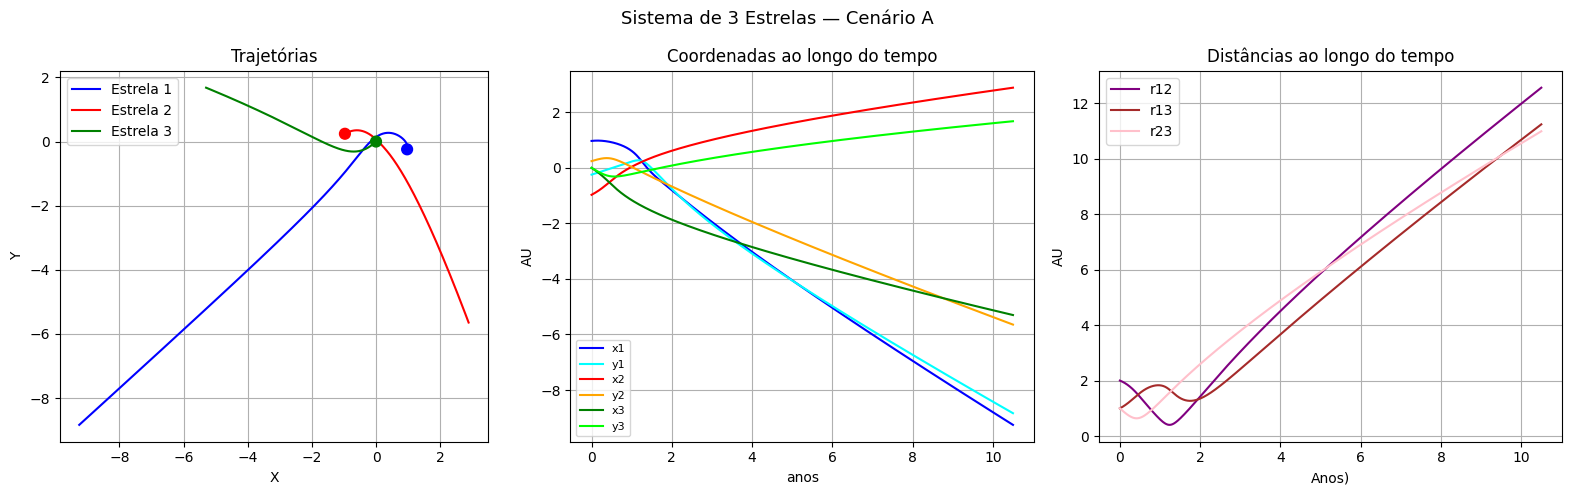

In [82]:
r12 = np.sqrt((x2-x1)**2 + (y2-y1)**2)
r13 = np.sqrt((x3-x1)**2 + (y3-y1)**2)
r23 = np.sqrt((x3-x2)**2 + (y3-y2)**2)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sistema de 3 Estrelas — Cenário A', fontsize=13)

# Gráfico 1: Trajetórias
axs[0].plot(x1, y1, label='Estrela 1', color='blue')
axs[0].plot(x2, y2, label='Estrela 2', color='red')
axs[0].plot(x3, y3, label='Estrela 3', color='green')
axs[0].scatter([x1[0], x2[0], x3[0]], [y1[0], y2[0], y3[0]],
               color=['blue','red','green'], s=60, zorder=5)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_title('Trajetórias')
axs[0].legend()
axs[0].set_aspect('equal')
axs[0].grid(True)

# Gráfico 2: Coordenadas ao longo do tempo
axs[1].plot(t, x1, label='x1', color='blue')
axs[1].plot(t, y1, label='y1', color='cyan')
axs[1].plot(t, x2, label='x2', color='red')
axs[1].plot(t, y2, label='y2', color='orange')
axs[1].plot(t, x3, label='x3', color='green')
axs[1].plot(t, y3, label='y3', color='lime')
axs[1].set_xlabel('anos')
axs[1].set_ylabel('AU')
axs[1].set_title('Coordenadas ao longo do tempo')
axs[1].legend(fontsize=8)
axs[1].grid(True)

# Gráfico 3: Distâncias ao longo do tempo
axs[2].plot(t, r12, label='r12', color='purple')
axs[2].plot(t, r13, label='r13', color='brown')
axs[2].plot(t, r23, label='r23', color='pink')
axs[2].set_xlabel('Anos)')
axs[2].set_ylabel('AU')
axs[2].set_title('Distâncias ao longo do tempo')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

e)

## Relatório

*(Escreva aqui seu relatório.)*